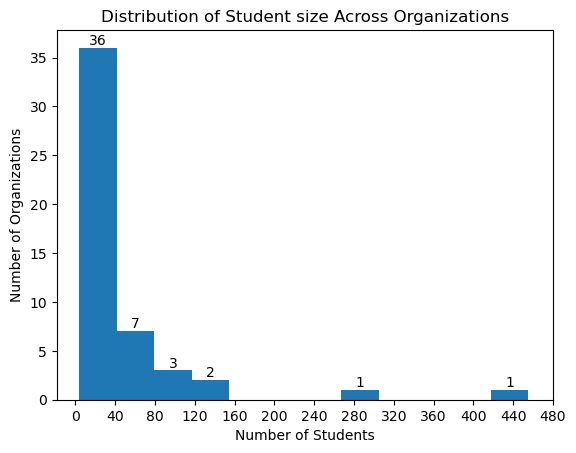

In [12]:
import matplotlib.pyplot as plt

data = [
67, 7, 32, 45, 4, 5, 21, 13, 13, 88,
6, 18, 5, 26, 128, 78, 47, 13, 101,
143, 50, 4, 45, 7, 35, 28, 45, 28, 32,
11, 455, 13, 34, 5, 15, 22, 29, 20,
30, 17, 12, 8, 6, 87, 294, 7, 17, 12,
5, 24
]

plt.figure()

counts, bin_edges, patches = plt.hist(data, bins=12)

# Add labels on top of bars
for count, x in zip(counts, bin_edges):
    if count > 0:
        plt.text(x + (bin_edges[1]-bin_edges[0])/2, count, int(count),
                 ha='center', va='bottom')

plt.title("Distribution of Student size Across Organizations")
plt.xlabel("Number of Students")
plt.xticks(range(0, 481, 40))
plt.ylabel("Number of Organizations")

plt.show()

In [10]:
import pandas as pd

# Create dataset manually (cleaned example)
data = [
(None,"Xeyr","Biology"),
(67,"Bəli","Biology"),
(7,"Xeyr","Agriculture"),
(None,None,None),
(32,"Bəli","Geography"),
(45,"Bəli","Chemistry"),
(4,"Xeyr","Agriculture"),
(5,"Bəli","Agriculture"),
(21,"Xeyr","Filology"),
(13,"Xeyr","Art studies"),
(13,"Xeyr",None),
(88,"Bəli","Law"),
(6,"Xeyr","Biology"),
(18,"Xeyr","Biology"),
(5,"Xeyr","Philosohpy"),
(26,"Xeyr","Agriculture"),
(128,"Xeyr","Medicine"),
(78,"Xeyr","law"),
(None,"Xeyr",None),
(47,"Xeyr","Economy"),
(13,"Bəli","Law"),
(101,"Xeyr","Philology"),
(None,None,None),
(143,"Bəli","Engineering"),
(50,"Xeyr","Economy"),
(4,"Xeyr","Law"),
(45,"Xeyr","Law"),
(7,"Xeyr","Art studies"),
(35,"Xeyr","Engineering"),
(28,"Xeyr","Economy"),
(45,"Xeyr","Multidisciplinary"),
(28,"Xeyr","Geology"),
(32,"Xeyr","Engineering"),
(11,"Xeyr","Biology"),
(455,"Xeyr","Mathematics"),
(13,"Xeyr","Engineering"),
(34,"Xeyr","Philology"),
(5,"Xeyr","Medicine"),
(15,"Xeyr","Engineering"),
(22,"Bəli","Medicine"),
(29,"Xeyr","Medicine"),
(20,"Xeyr","Engineering"),
(30,"Bəli","Engineering"),
(17,"Xeyr","Pedogogy"),
(12,"Xeyr","Geology"),
(8,"Xeyr","Biology"),
(6,"Xeyr","Agriculture"),
(87,"Xeyr","Philology"),
(294,"Xeyr","Engineering"),
(7,"Bəli","Geology"),
(17,"Bəli","Economy"),
(12,"Bəli","Geology"),
(5,"Xeyr","Art studies"),
(24,"Bəli","Engineering")
]

df = pd.DataFrame(data, columns=["Number","Funding","Field"])

# -----------------------------
# 1. CLEAN DATA
# -----------------------------

# Remove rows with missing Number or Funding
df = df.dropna(subset=["Number", "Funding"])

# Create size categories
def size_category(x):
    if x < 20:
        return "Small"
    elif x <= 80:
        return "Medium"
    else:
        return "Large"

In [11]:
df

,Number,Funding,Field
1,67.0,Bəli,Biology
2,7.0,Xeyr,Agriculture
4,32.0,Bəli,Geography
5,45.0,Bəli,Chemistry
6,4.0,Xeyr,Agriculture
7,5.0,Bəli,Agriculture
8,21.0,Xeyr,Filology
9,13.0,Xeyr,Art studies
10,13.0,Xeyr,None
11,88.0,Bəli,Law


In [12]:
df["Size"] = df["Number"].apply(size_category)

# Cross-tab: Funding vs Size
ct_size = pd.crosstab(df["Size"], df["Funding"], normalize="index")*100

# Cross-tab: Funding vs Field
ct_field = pd.crosstab(df["Field"], df["Funding"], normalize="index")*100

print(ct_size)
print(ct_field)

Funding       Bəli       Xeyr
Size                         
Large    28.571429  71.428571
Medium   30.000000  70.000000
Small    21.739130  78.260870
Funding                  Bəli        Xeyr
Field                                    
Agriculture         20.000000   80.000000
Art studies          0.000000  100.000000
Biology             20.000000   80.000000
Chemistry          100.000000    0.000000
Economy             25.000000   75.000000
Engineering         33.333333   66.666667
Filology             0.000000  100.000000
Geography          100.000000    0.000000
Geology             50.000000   50.000000
Law                 50.000000   50.000000
Mathematics          0.000000  100.000000
Medicine            25.000000   75.000000
Multidisciplinary    0.000000  100.000000
Pedogogy             0.000000  100.000000
Philology            0.000000  100.000000
Philosohpy           0.000000  100.000000
law                  0.000000  100.000000


In [13]:
import pandas as pd
from scipy.stats import chi2_contingency

# Crosstab (counts, NOT percentages)
ct_size_counts = pd.crosstab(df["Size"], df["Funding"])

print(ct_size_counts)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(ct_size_counts)

print("\nChi-square:", chi2)
print("p-value:", p)

Funding  Bəli  Xeyr
Size               
Large       2     5
Medium      6    14
Small       5    18

Chi-square: 0.4074069291460597
p-value: 0.8157042205263871


In [14]:
# Crosstab for field (counts)
ct_field_counts = pd.crosstab(df["Field"], df["Funding"])

print(ct_field_counts)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(ct_field_counts)

print("\nChi-square:", chi2)
print("p-value:", p)

Funding            Bəli  Xeyr
Field                        
Agriculture           1     4
Art studies           0     3
Biology               1     4
Chemistry             1     0
Economy               1     3
Engineering           3     6
Filology              0     1
Geography             1     0
Geology               2     2
Law                   2     2
Mathematics           0     1
Medicine              1     3
Multidisciplinary     0     1
Pedogogy              0     1
Philology             0     3
Philosohpy            0     1
law                   0     1

Chi-square: 12.574572649572648
p-value: 0.7035716937815222


In [15]:
def group_field(field):
    if field in ["Biology", "Chemistry", "Geography", "Geology", "Mathematics"]:
        return "Natural Sciences"
    elif field in ["Engineering"]:
        return "Engineering"
    elif field in ["Medicine"]:
        return "Medical"
    elif field in ["Agriculture"]:
        return "Agriculture"
    else:
        return "Social & Humanities"

df["Field_group"] = df["Field"].apply(group_field)

In [16]:
import pandas as pd

ct_group = pd.crosstab(df["Field_group"], df["Funding"], normalize="index") * 100
print(ct_group)

Funding                   Bəli       Xeyr
Field_group                              
Agriculture          20.000000  80.000000
Engineering          33.333333  66.666667
Medical              25.000000  75.000000
Natural Sciences     41.666667  58.333333
Social & Humanities  15.000000  85.000000


In [17]:
from scipy.stats import chi2_contingency

ct_counts = pd.crosstab(df["Field_group"], df["Funding"])

chi2, p, dof, expected = chi2_contingency(ct_counts)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 3.1358281358281364
p-value: 0.535357706462259


<Figure size 700x400 with 0 Axes>

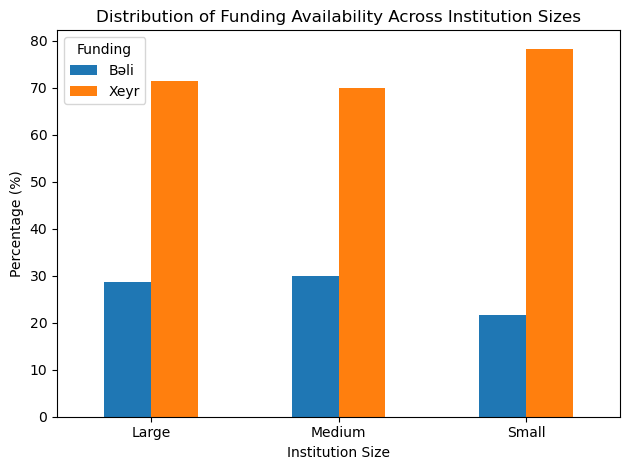

In [18]:
import matplotlib.pyplot as plt

# Crosstab with percentages
ct_size = pd.crosstab(df["Size"], df["Funding"], normalize='index') * 100

# Plot
plt.figure(figsize=(7,4))
ct_size.plot(kind='bar')

# Labels
plt.xlabel("Institution Size")
plt.ylabel("Percentage (%)")
plt.title("Distribution of Funding Availability Across Institution Sizes")
plt.xticks(rotation=0)

plt.legend(title="Funding")

plt.tight_layout()

# Save (publication quality)
plt.savefig('../figures/funding_by_size.png', dpi=300, bbox_inches='tight')
plt.savefig('funding_by_size.pdf', bbox_inches='tight')
plt.show()

<Figure size 700x400 with 0 Axes>

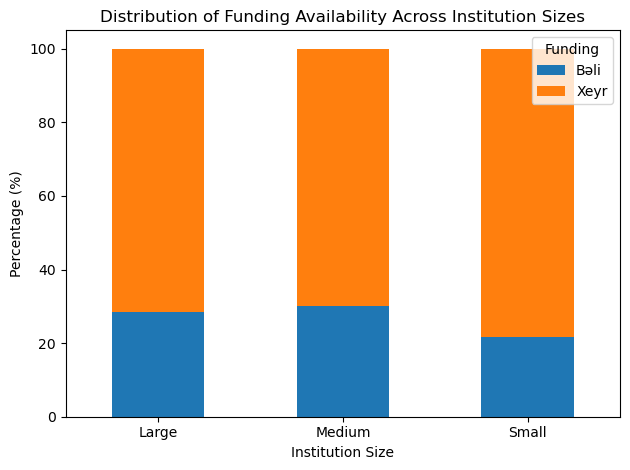

In [22]:
plt.figure(figsize=(7,4))
ct_size.plot(kind='bar', stacked=True)

plt.xlabel("Institution Size")
plt.ylabel("Percentage (%)")
plt.title("Distribution of Funding Availability Across Institution Sizes")
plt.xticks(rotation=0)

plt.legend(title="Funding")

plt.tight_layout()

plt.savefig('../figures/funding_by_size_stacked.png', dpi=300, bbox_inches='tight')
plt.savefig('funding_by_size_stacked.pdf', bbox_inches='tight')

plt.show()

<Axes: xlabel='Size'>

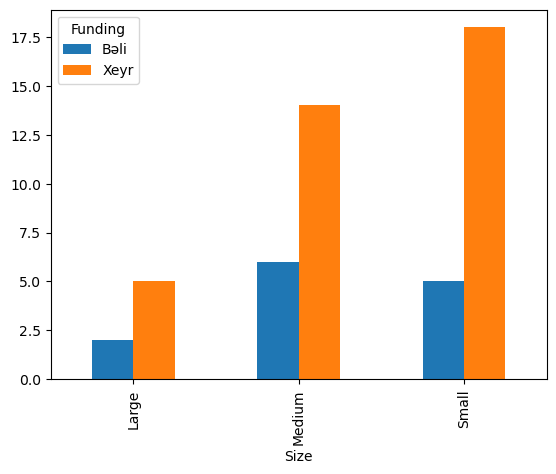

In [23]:
ct_size_counts = pd.crosstab(df["Size"], df["Funding"])

ct_size_counts.plot(kind='bar')

<Figure size 800x400 with 0 Axes>

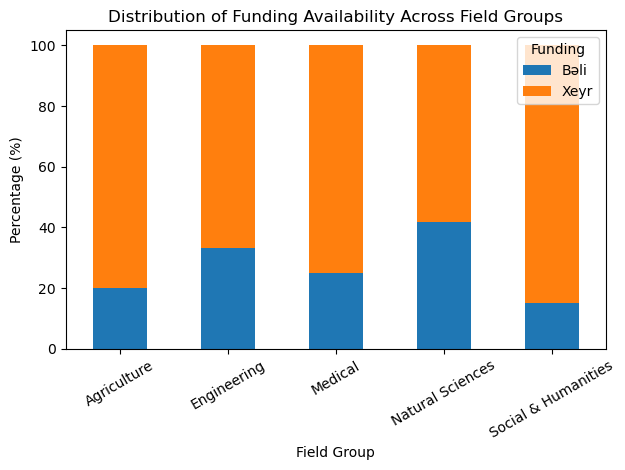

In [24]:
# Crosstab (percentage)
ct_field = pd.crosstab(df["Field_group"], df["Funding"], normalize='index') * 100

# Plot (stacked — best for publication)
plt.figure(figsize=(8,4))
ct_field.plot(kind='bar', stacked=True)

# Labels
plt.xlabel("Field Group")
plt.ylabel("Percentage (%)")
plt.title("Distribution of Funding Availability Across Field Groups")
plt.xticks(rotation=30)

plt.legend(title="Funding")

plt.tight_layout()
# Save (high quality)
plt.savefig('../figures/funding_by_field_group.png', dpi=300, bbox_inches='tight')
plt.savefig('funding_by_field_group.pdf', bbox_inches='tight')

plt.show()

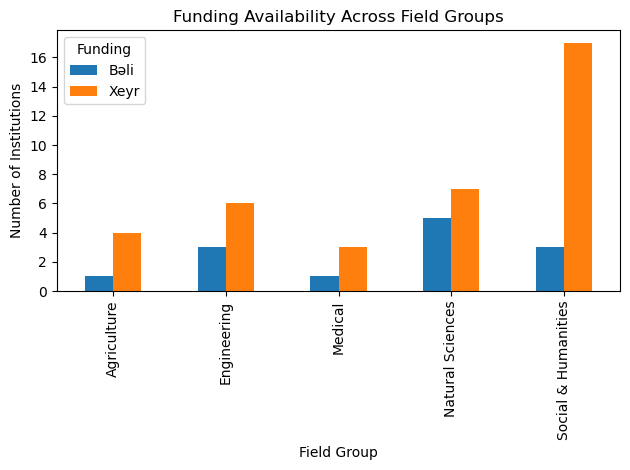

In [25]:
ct_field_counts = pd.crosstab(df["Field_group"], df["Funding"])

ct_field_counts.plot(kind='bar')

plt.xlabel("Field Group")
plt.ylabel("Number of Institutions")
plt.title("Funding Availability Across Field Groups")

plt.tight_layout()
plt.savefig('../figures/funding_by_field_group_counts.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
responses = [
["Q1"],
["I1"],
["B1"],
["F1","Inter1","Infras1"],
["F1","Inter1","Infras2"],
["F1","B2"],
["E1"],
["Inter1"],
["Q2"],
["Q1"],
["F1","Inter1","Infras1"],
["B2"],
["E1","F1"],
["Q2"],
["B1"],
["B2"],
["Q1"],
["B2"],
["B2"],
["E1"],
["S1"],
["B2","B1","Q2"],
["B1"],
["B2"],
["F1"],
["S1","Q3"],
["B2","B1"],
["Q3","Inter1","F1"],
["B3"],
["Infras1"],
["E1","B1","B2"],
["B2"],
["B2"],
["B3"],
["B2"],
["B2"],
["Q1"]
]

In [27]:
from collections import Counter

all_codes = [code for r in responses for code in r]
freq = Counter(all_codes)

print(freq)

Counter({'B2': 13, 'F1': 7, 'B1': 6, 'Inter1': 5, 'Q1': 4, 'E1': 4, 'Infras1': 3, 'Q2': 3, 'S1': 2, 'Q3': 2, 'B3': 2, 'I1': 1, 'Infras2': 1})


In [28]:
from itertools import combinations
from collections import Counter

co_occurrence = Counter()

for r in responses:
    if len(r) > 1:
        for pair in combinations(r, 2):
            co_occurrence[pair] += 1

print(co_occurrence)

Counter({('F1', 'Inter1'): 3, ('F1', 'Infras1'): 2, ('Inter1', 'Infras1'): 2, ('B2', 'B1'): 2, ('F1', 'Infras2'): 1, ('Inter1', 'Infras2'): 1, ('F1', 'B2'): 1, ('E1', 'F1'): 1, ('B2', 'Q2'): 1, ('B1', 'Q2'): 1, ('S1', 'Q3'): 1, ('Q3', 'Inter1'): 1, ('Q3', 'F1'): 1, ('Inter1', 'F1'): 1, ('E1', 'B1'): 1, ('E1', 'B2'): 1, ('B1', 'B2'): 1})


In [29]:
import pandas as pd

freq_df = pd.DataFrame(freq.items(), columns=["Code","Frequency"])
freq_df = freq_df.sort_values(by="Frequency", ascending=False)

print(freq_df)

       Code  Frequency
7        B2         13
3        F1          7
2        B1          6
4    Inter1          5
0        Q1          4
8        E1          4
5   Infras1          3
9        Q2          3
10       S1          2
11       Q3          2
12       B3          2
1        I1          1
6   Infras2          1


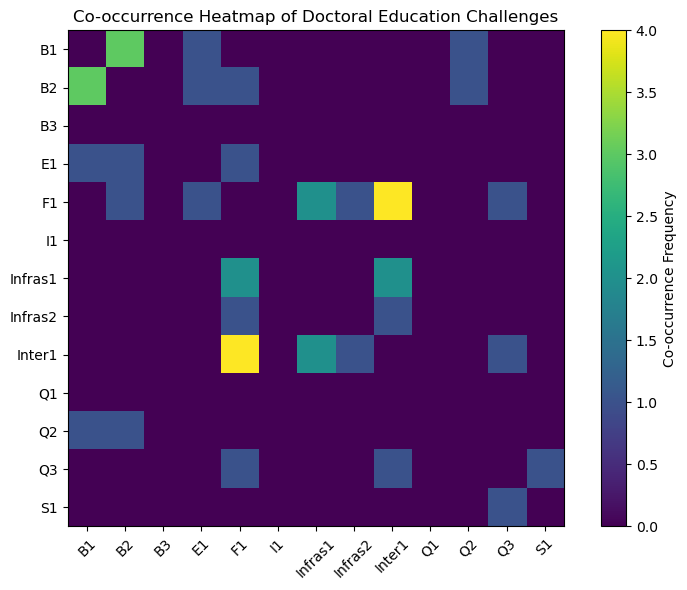

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

# Your coded responses
responses = [
["Q1"], ["I1"], ["B1"],
["F1","Inter1","Infras1"],
["F1","Inter1","Infras2"],
["F1","B2"], ["E1"], ["Inter1"],
["Q2"], ["Q1"],
["F1","Inter1","Infras1"],
["B2"], ["E1","F1"],
["Q2"], ["B1"], ["B2"], ["Q1"],
["B2"], ["B2"], ["E1"], ["S1"],
["B2","B1","Q2"], ["B1"], ["B2"],
["F1"], ["S1","Q3"],
["B2","B1"],
["Q3","Inter1","F1"],
["B3"], ["Infras1"],
["E1","B1","B2"],
["B2"], ["B2"], ["B3"], ["B2"], ["B2"],
["Q1"]
]

# Step 1: Get all unique codes
codes = sorted(set(code for r in responses for code in r))

# Step 2: Initialize matrix
co_matrix = pd.DataFrame(0, index=codes, columns=codes)

# Step 3: Fill co-occurrence counts
for r in responses:
    for a, b in combinations(r, 2):
        co_matrix.loc[a, b] += 1
        co_matrix.loc[b, a] += 1  # symmetric

# Step 4: Plot heatmap
plt.figure(figsize=(8,6))

plt.imshow(co_matrix, interpolation='nearest')
plt.colorbar(label="Co-occurrence Frequency")

plt.xticks(range(len(codes)), codes, rotation=45)
plt.yticks(range(len(codes)), codes)

plt.title("Co-occurrence Heatmap of Doctoral Education Challenges")

plt.tight_layout()

# Save (publication quality)
plt.savefig("../figures/heatmap.png", dpi=300, bbox_inches='tight')
plt.savefig("heatmap.pdf", bbox_inches='tight')

plt.show()